# Metoda A — Silne blind spoty: opis + kategoryzacja (Qwen)

Dwufazowe podejście:
- **Faza 1** — Qwen opisuje każdy obrazek osobno → CSV z opisami (`descriptions_*.csv`)
- **Faza 2** — Qwen porównuje dwa opisy tekstowo i przypisuje kategorie różnic → CSV (`categorized_*.csv`)
- **Wizualizacja** — heatmapa kategoria × model bazowy + przykładowe pary per kategoria

## 1. Importy

In [2]:
import gc
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from IPython.display import display as ipy_display
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {DEVICE}")

Urządzenie: cuda


## 2. Konfiguracja

In [3]:
SELECTION      = ["clip_caltech_blind_spots.csv", "clip_imagenet_test_blind_spots.csv", 
 "dino_caltech_blind_spots.csv", "dino_imagenet_test_blind_spots.csv", 
 "siglip_caltech_blind_spots.csv", "siglip_imagenet_test_blind_spots.csv"]   # "caltech" | "imagenet" | "all" | lista plików
REF_THRESHOLD  = 0.65

QWEN_ID        = "Qwen/Qwen2-VL-2B-Instruct"
SIMILARITY_DIR = Path("similarity_results")
CACHE_DIR      = Path("img_cache")
OUTPUT_DIR     = Path("results_A")
OUTPUT_DIR.mkdir(exist_ok=True)

MAX_NEW_TOKENS_DESC = 500  # dla opisów obrazków
MAX_NEW_TOKENS_CAT  = 30   # dla kategoryzacji (krótka lista)

---
## FAZA 1 — Generowanie opisów obrazków

Uruchom sekcje 3–8 aby wygenerować opisy i zapisać do CSV.

## 3. Filtrowanie silnych blind spotów

In [4]:
all_csvs = sorted(SIMILARITY_DIR.glob("*.csv"))

if SELECTION == "caltech":
    selected = [f for f in all_csvs if "caltech" in f.name]
    run_label = "caltech"
elif SELECTION == "imagenet":
    selected = [f for f in all_csvs if "imagenet" in f.name]
    run_label = "imagenet"
elif SELECTION == "all":
    selected = all_csvs
    run_label = "all"
else:
    selected = [SIMILARITY_DIR / f for f in SELECTION]
    stems = [Path(f).stem.replace("_blind_spots", "") for f in SELECTION]
    run_label = "_".join(stems)

desc_path = OUTPUT_DIR / f"descriptions_{run_label}.csv"
cat_path  = OUTPUT_DIR / f"categorized_{run_label}.csv"


def filter_strong(csv_path: Path, threshold: float) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=";", index_col=0).reset_index(drop=True)
    mask = (df["score_ref_1"] < threshold) & (df["score_ref_2"] < threshold)
    return df[mask].reset_index(drop=True)


def dataset_key(csv_path) -> str:
    return "caltech" if "caltech" in str(csv_path) else "imagenet"


print(f"Próg: score_ref_1 < {REF_THRESHOLD} AND score_ref_2 < {REF_THRESHOLD}")
print(f"Opisy     -> {desc_path}")
print(f"Kategorie -> {cat_path}\n")

filtered_dfs = {}
total_before, total_after = 0, 0
for csv_path in selected:
    df_all = pd.read_csv(csv_path, sep=";", index_col=0)
    df_f   = filter_strong(csv_path, REF_THRESHOLD)
    filtered_dfs[csv_path] = df_f
    total_before += len(df_all)
    total_after  += len(df_f)
    print(f"  {csv_path.name}: {len(df_all)} -> {len(df_f)} par")

print(f"\nLacznie: {total_before} -> {total_after} par")

Próg: score_ref_1 < 0.65 AND score_ref_2 < 0.65
Opisy     -> results_A\descriptions_clip_caltech_clip_imagenet_test_dino_caltech_dino_imagenet_test_siglip_caltech_siglip_imagenet_test.csv
Kategorie -> results_A\categorized_clip_caltech_clip_imagenet_test_dino_caltech_dino_imagenet_test_siglip_caltech_siglip_imagenet_test.csv

  clip_caltech_blind_spots.csv: 194 -> 7 par
  clip_imagenet_test_blind_spots.csv: 208 -> 2 par
  dino_caltech_blind_spots.csv: 417 -> 6 par
  dino_imagenet_test_blind_spots.csv: 697 -> 18 par
  siglip_caltech_blind_spots.csv: 3 -> 1 par
  siglip_imagenet_test_blind_spots.csv: 46 -> 31 par

Lacznie: 1565 -> 65 par


## 4. Logowanie HuggingFace

In [ ]:
# from huggingface_hub import notebook_login
# notebook_login()

## 5. Wczytanie datasetów

In [5]:
def add_index(sample, idx):
    sample["id"] = idx
    return sample

DATASETS = {}

if any("caltech" in f.name for f in selected):
    print("Wczytywanie Caltech101...")
    DATASETS["caltech"] = load_dataset("flwrlabs/caltech101", split="train", trust_remote_code=True)
    print("  Caltech101 OK")

if any("imagenet" in f.name for f in selected):
    print("Wczytywanie ImageNet-1k (test, streaming)...")
    ds = load_dataset("imagenet-1k", split="test", streaming=True, trust_remote_code=True)
    DATASETS["imagenet"] = ds.map(add_index, with_indices=True)
    print("  ImageNet-test (streaming) OK")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flwrlabs/caltech101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Wczytywanie Caltech101...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Caltech101 OK
Wczytywanie ImageNet-1k (test, streaming)...


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

  ImageNet-test (streaming) OK


## 6. Cache obrazków

In [6]:
def prefetch_pairs(df: pd.DataFrame, key: str) -> None:
    ds = DATASETS[key]
    ids = set(df["id_1"].astype(int)) | set(df["id_2"].astype(int))
    out_dir = CACHE_DIR / key
    out_dir.mkdir(parents=True, exist_ok=True)
    missing = {i for i in ids if not (out_dir / f"{i}.jpg").exists()}
    if not missing:
        print(f"  [{key}] wszystko w cache")
        return
    print(f"  Pobieram {len(missing)} obrazkow [{key}]...")
    if key == "caltech":
        for i in tqdm(sorted(missing)):
            ds[i]["image"].convert("RGB").save(out_dir / f"{i}.jpg", "JPEG")
    else:
        max_id = max(missing)
        for cur, sample in enumerate(tqdm(iter(ds), total=max_id + 1)):
            if cur in missing:
                sample["image"].convert("RGB").save(out_dir / f"{cur}.jpg", "JPEG")
                missing.discard(cur)
            if cur >= max_id or not missing:
                break


for csv_path, df_f in filtered_dfs.items():
    if df_f.empty:
        continue
    prefetch_pairs(df_f, dataset_key(csv_path))
print("Cache gotowy.")

  [caltech] wszystko w cache
  [imagenet] wszystko w cache
  [caltech] wszystko w cache
  [imagenet] wszystko w cache
  [caltech] wszystko w cache
  [imagenet] wszystko w cache
Cache gotowy.


## 7. Ładowanie Qwena

In [7]:
print(f"Ladowanie Qwen ({QWEN_ID})...")
qwen_processor = AutoProcessor.from_pretrained(
    QWEN_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,
)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
qwen_model.eval()
devices = {str(p.device) for p in qwen_model.parameters()}
print(f"  Qwen gotowy | urzadzenia: {', '.join(sorted(devices))}")

Ladowanie Qwen (Qwen/Qwen2-VL-2B-Instruct)...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

  Qwen gotowy | urzadzenia: cuda:0


## 8. Generowanie opisów i zapis do CSV

In [8]:
DESCRIBE_PROMPT = (
    "Describe this image precisely. Focus on:\n"
    "1. Main subject: exact species, breed, or type; color, size, distinctive markings\n"
    "2. Subject's pose, orientation, and position in the frame\n"
    "3. Background: specific objects present, scene type, environment details\n"
    "4. Overall color palette and lighting conditions\n"
    "Write 3-4 sentences in plain text."
)


def qwen_describe_single(img: Image.Image) -> str:
    content = [{"type": "image", "image": img}, {"type": "text", "text": DESCRIBE_PROMPT}]
    messages = [{"role": "user", "content": content}]
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_processor(text=[text], images=[img], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        gen = qwen_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_DESC)
    trimmed = gen[0][inputs.input_ids.shape[1]:]
    del inputs, gen
    torch.cuda.empty_cache()
    return qwen_processor.decode(trimmed, skip_special_tokens=True).strip()


all_results = []
for csv_path, df in filtered_dfs.items():
    if df.empty:
        print(f"\n{csv_path.name} — brak par, pomijam")
        continue
    key = dataset_key(csv_path)
    print(f"\n{csv_path.name}  ({len(df)} par)")
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img1 = Image.open(CACHE_DIR / key / f"{int(row['id_1'])}.jpg").convert("RGB")
            img2 = Image.open(CACHE_DIR / key / f"{int(row['id_2'])}.jpg").convert("RGB")
            desc1 = qwen_describe_single(img1)
            desc2 = qwen_describe_single(img2)
        except Exception as e:
            print(f"  BLAD {int(row['id_1'])}-{int(row['id_2'])}: {e}")
            desc1, desc2 = "", ""
        result = row.to_dict()
        result.update({"desc_1": desc1, "desc_2": desc2, "source_file": str(csv_path)})
        rows.append(result)
        gc.collect()
    all_results.extend(rows)
    print(f"  {len(rows)} par OK")

desc_df = pd.DataFrame(all_results)
desc_df.to_csv(desc_path, sep=";", index=False)
print(f"\nZapisano: {desc_path}  ({len(desc_df)} wierszy)")
ipy_display(desc_df[["id_1", "id_2", "base_name", "score_base", "desc_1", "desc_2"]].head(3))


clip_caltech_blind_spots.csv  (7 par)


  0%|          | 0/7 [00:00<?, ?it/s]

  7 par OK

clip_imagenet_test_blind_spots.csv  (2 par)


  0%|          | 0/2 [00:00<?, ?it/s]

  2 par OK

dino_caltech_blind_spots.csv  (6 par)


...

  0%|          | 0/1 [00:00<?, ?it/s]

  1 par OK

siglip_imagenet_test_blind_spots.csv  (31 par)


  0%|          | 0/31 [00:00<?, ?it/s]

  31 par OK

Zapisano: results_A\descriptions_clip_caltech_clip_imagenet_test_dino_caltech_dino_imagenet_test_siglip_caltech_siglip_imagenet_test.csv  (65 wierszy)


,id_1,id_2,base_name,score_base,desc_1,desc_2
0,279,5645,CLIP,0.954017,The image depicts a person with shoulder-lengt...,The image depicts a person with light skin and...
1,754,8134,CLIP,0.960434,The image depicts a red stop sign with a white...,The image depicts a red stop sign with the wor...
2,754,4125,CLIP,0.955285,The image depicts a red stop sign with a white...,The image depicts a red stop sign with the wor...


## 8b. Podgląd wygenerowanych opisów

Wyświetlam 20 z 65 par


C:\Users\alapr\AppData\Local\Temp\ipykernel_21876\3439404555.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


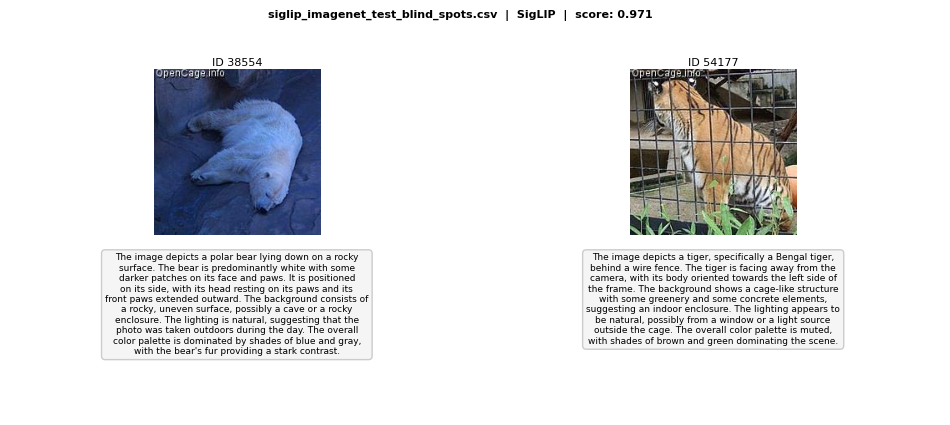

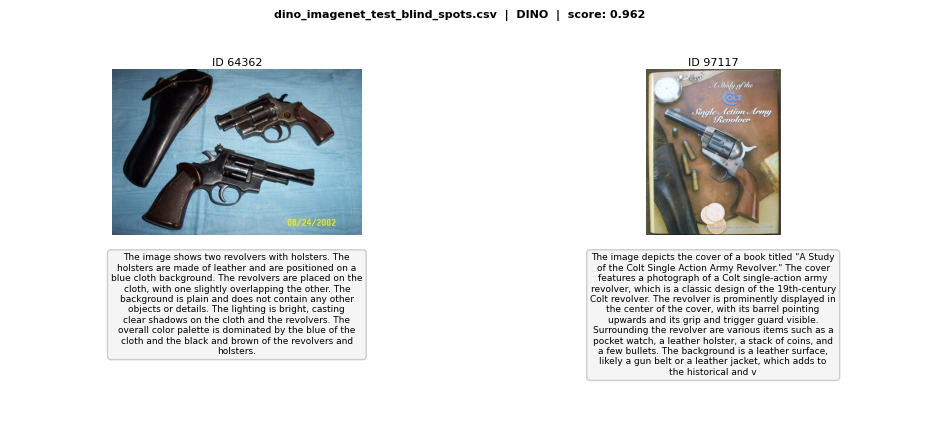

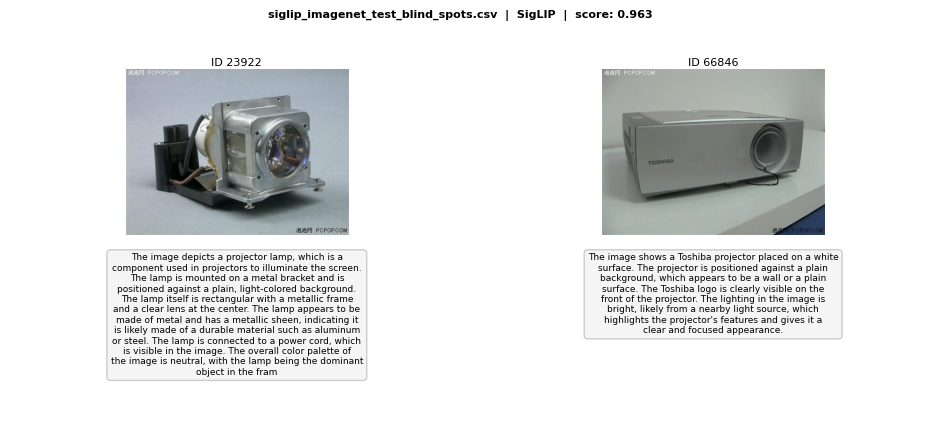

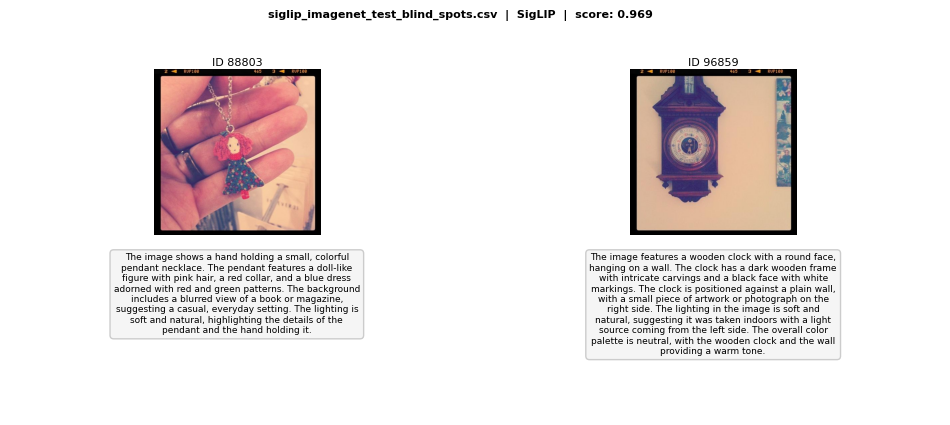

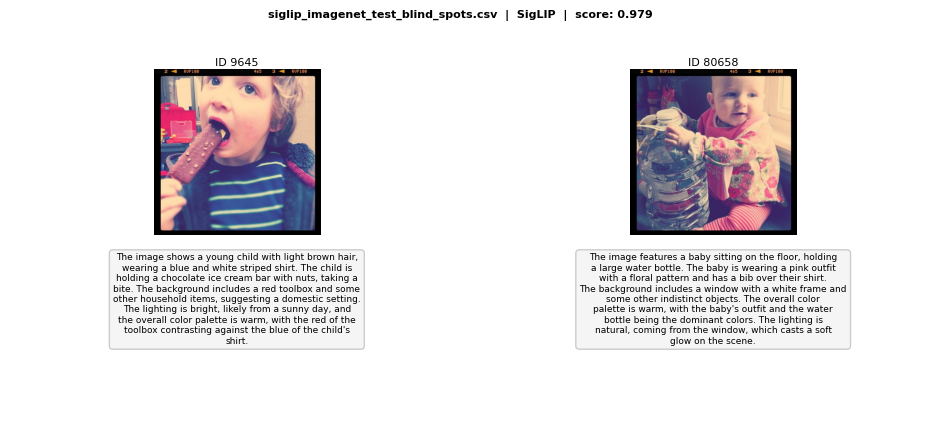

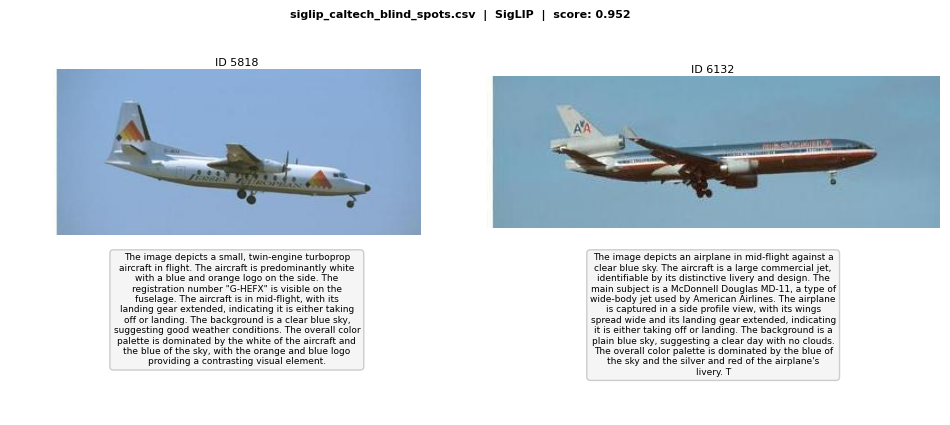

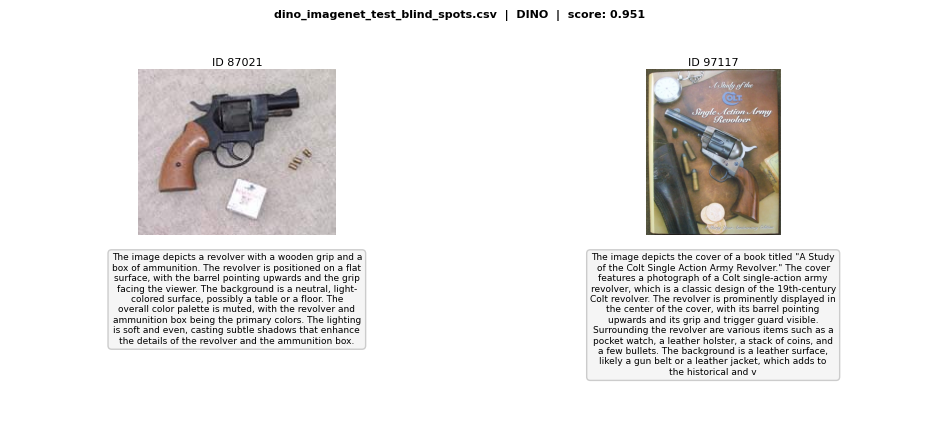

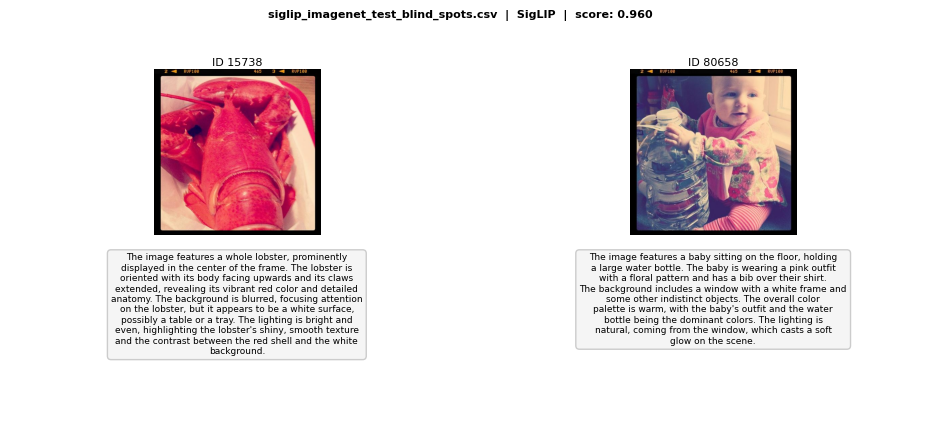

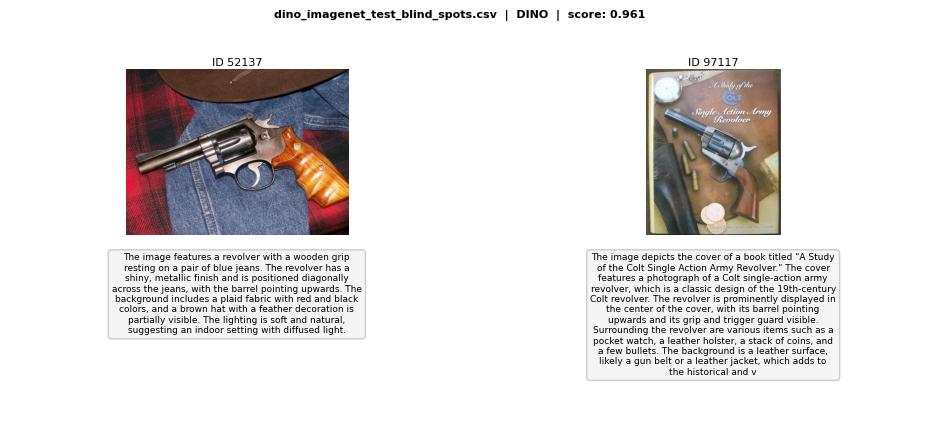

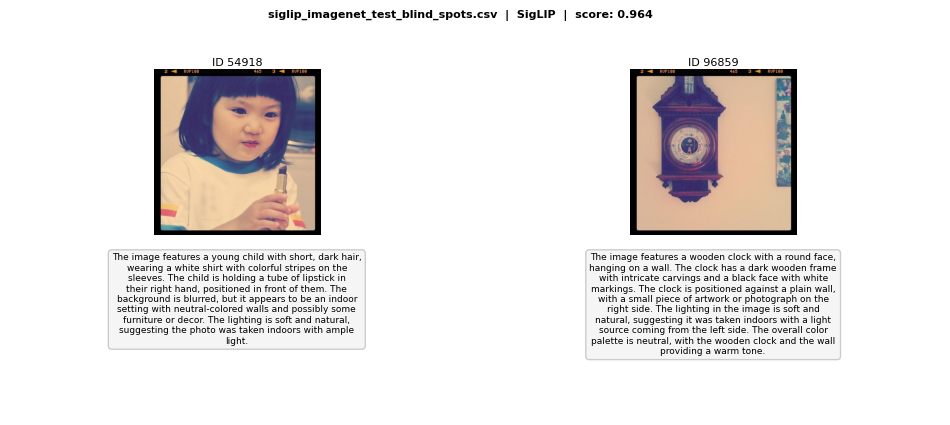

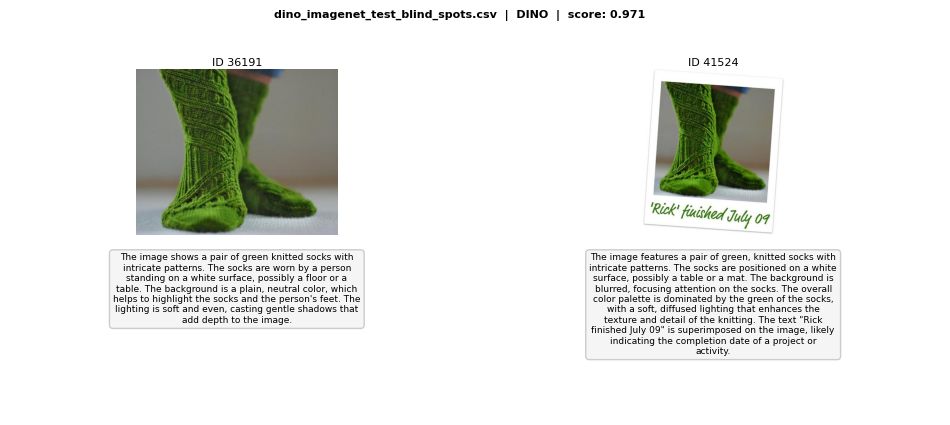

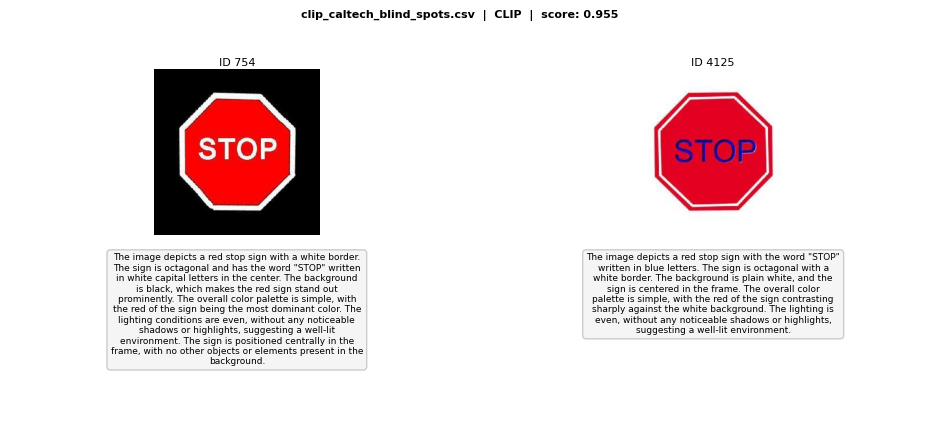

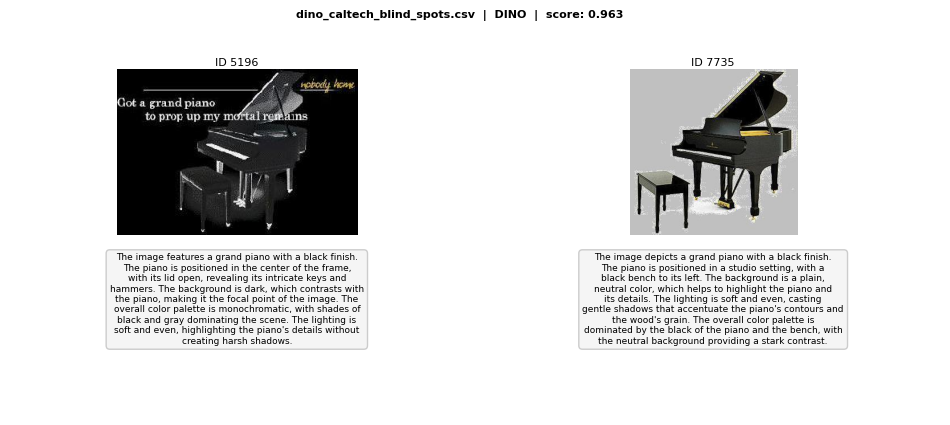

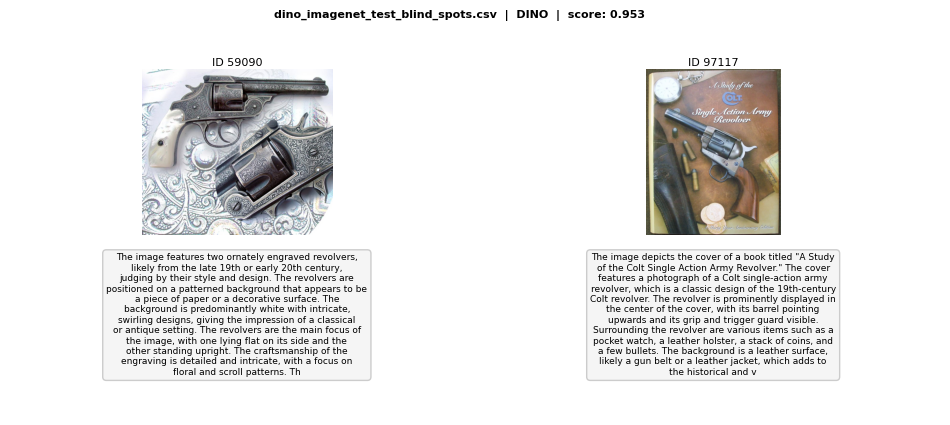

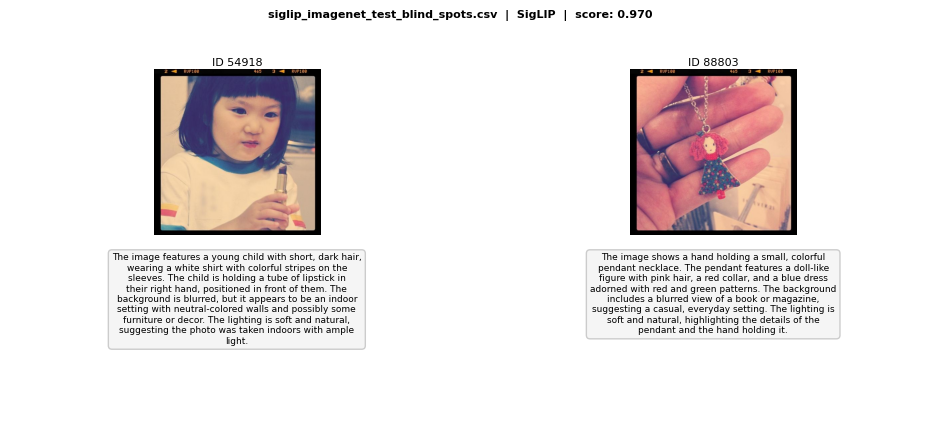

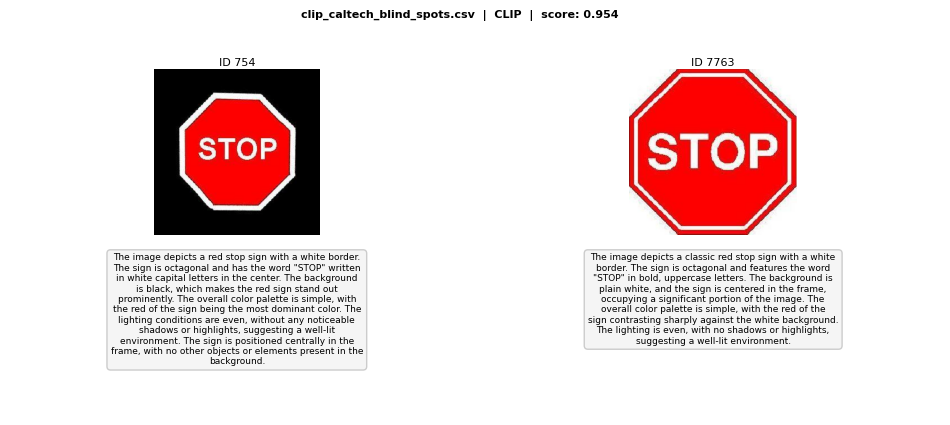

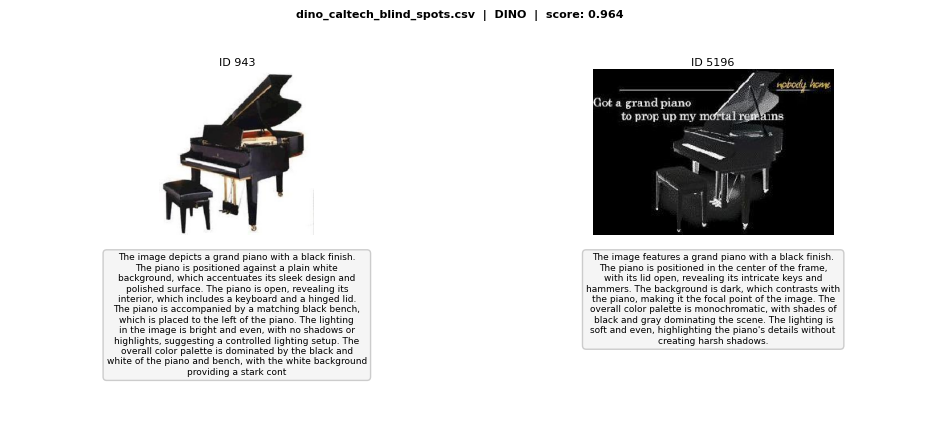

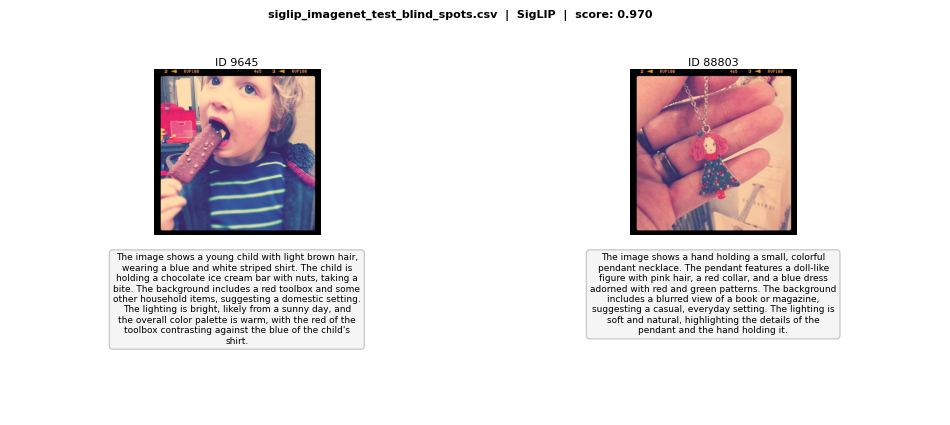

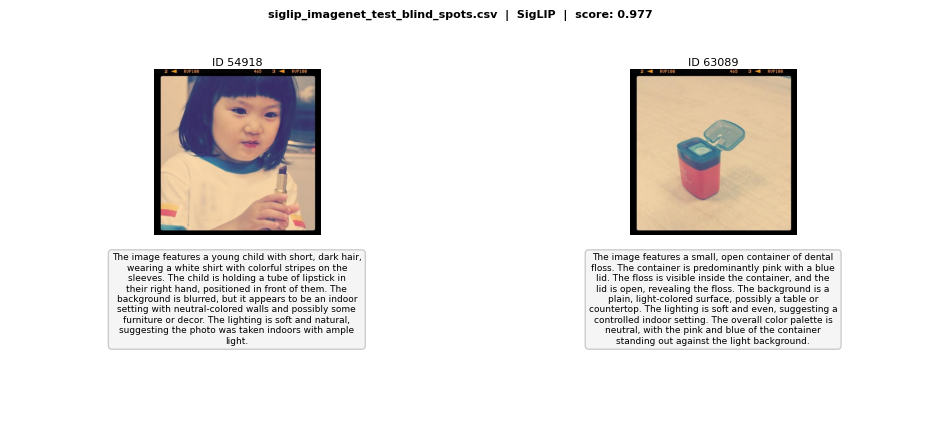

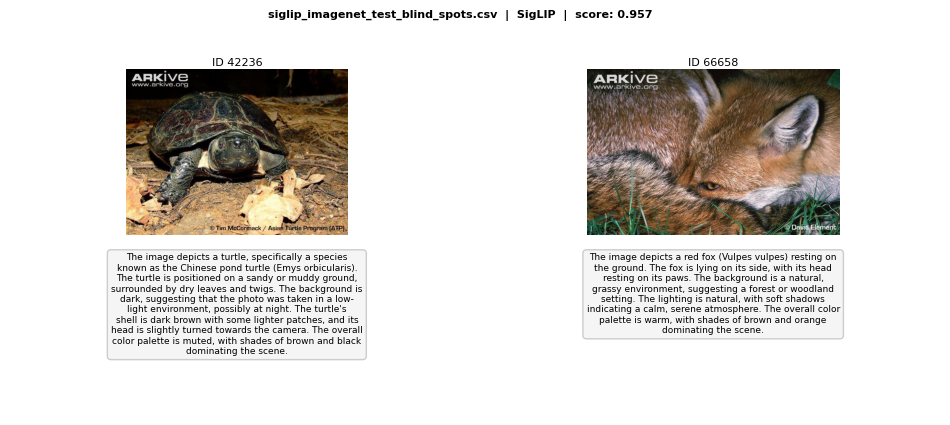

In [10]:
DISPLAY_N_DESC = 20  # ile par wyświetlić

sample_df = desc_df.sample(n=min(DISPLAY_N_DESC, len(desc_df)), random_state=0).reset_index(drop=True)
print(f"Wyświetlam {len(sample_df)} z {len(desc_df)} par")

for _, row in sample_df.iterrows():
    key = dataset_key(Path(row["source_file"]))
    try:
        img1 = Image.open(CACHE_DIR / key / f"{int(row['id_1'])}.jpg")
        img2 = Image.open(CACHE_DIR / key / f"{int(row['id_2'])}.jpg")
    except FileNotFoundError:
        continue

    fig = plt.figure(figsize=(12, 4.5))
    gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 3], hspace=0.08, wspace=0.05)

    for col, (img, lbl) in enumerate([
        (img1, f"ID {int(row['id_1'])}"),
        (img2, f"ID {int(row['id_2'])}"),
    ]):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(img)
        ax.set_title(lbl, fontsize=8, pad=2)
        ax.axis("off")

    for col, desc_key in enumerate(["desc_1", "desc_2"]):
        ax_txt = fig.add_subplot(gs[1, col])
        ax_txt.axis("off")
        desc = textwrap.fill(str(row.get(desc_key, ""))[:600], width=55)
        ax_txt.text(
            0.5, 0.97, desc,
            ha="center", va="top", fontsize=6.5,
            bbox=dict(facecolor="#f5f5f5", edgecolor="#ccc", boxstyle="round,pad=0.4"),
            transform=ax_txt.transAxes,
        )

    src = Path(row["source_file"]).name
    plt.suptitle(
        f"{src}  |  {row['base_name']}  |  score: {row['score_base']:.3f}",
        fontsize=8, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()
    print()

---
## FAZA 2 — Kategoryzacja różnic na podstawie opisów

Można uruchomić **bez Fazy 1** jeśli CSV z opisami już istnieje.
Wystarczy ustawić `DESC_CSV` i uruchomić komórki 9–11.

## 9. Wczytanie opisów z CSV

In [8]:
# Ustaw sciezke jesli uruchamiasz Faze 2 bez Fazy 1:
# DESC_CSV = Path("results_A/descriptions_imagenet.csv")
DESC_CSV = OUTPUT_DIR / f"descriptions_{run_label}.csv"

desc_df  = pd.read_csv(DESC_CSV, sep=";")
cat_path = DESC_CSV.parent / DESC_CSV.name.replace("descriptions_", "categorized_")
print(f"Wczytano: {len(desc_df)} par z {DESC_CSV}")
ipy_display(desc_df[["id_1", "id_2", "base_name", "desc_1", "desc_2"]].head(2))

Wczytano: 23 par z results_A\descriptions_caltech.csv


,id_1,id_2,base_name,desc_1,desc_2
0,279,5645,CLIP,The image depicts a person with shoulder-lengt...,The image depicts a person with light skin and...
1,754,8134,CLIP,The image depicts a red stop sign with a white...,The image depicts a red stop sign with the wor...


## 10. Ładowanie Qwena (jeśli nie załadowany)

In [ ]:
if "qwen_model" not in dir():
    _QWEN_ID = "Qwen/Qwen2-VL-2B-Instruct"
    DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
    MAX_NEW_TOKENS_CAT = 30
    print(f"Ladowanie Qwen ({_QWEN_ID})...")
    qwen_processor = AutoProcessor.from_pretrained(_QWEN_ID)
    qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
        _QWEN_ID, torch_dtype=torch.bfloat16, device_map="auto"
    )
    qwen_model.eval()
    print("  Qwen gotowy")
else:
    print("Qwen juz zaladowany.")

## 11. Kategoryzacja par i zapis do CSV

In [12]:
CATEGORIES = [
    "SUBJECT_TYPE",        # inny gatunek / rasa / kategoria
    "SUBJECT_APPEARANCE",  # inne kolory / umaszczenie / rozmiar
    "SUBJECT_POSE",        # inna poza / orientacja
    "BACKGROUND_OBJECTS",  # inne obiekty w tle
    "BACKGROUND_SETTING",  # inne srodowisko / otoczenie
    "COLORS_LIGHTING",     # inne globalne kolory / oswietlenie
    "NO_DIFFERENCE",       # brak roznic
]

# Prompt v1
# CATEGORIZE_TEMPLATE = (
#     "Compare these two image descriptions and identify differences.\n\n"
#     "Image 1: {desc_1}\n\n"
#     "Image 2: {desc_2}\n\n"
#     "From the list below, pick ALL categories where the images differ:\n"
#     "SUBJECT_TYPE, SUBJECT_APPEARANCE, SUBJECT_POSE, "
#     "BACKGROUND_OBJECTS, BACKGROUND_SETTING, COLORS_LIGHTING, NO_DIFFERENCE\n\n"
#     "Reply with only the matching category names, comma-separated. No explanation."
# )

# Prompt v2
CATEGORIZE_TEMPLATE = (
    "[Image 1] {desc_1}\n\n"
    "[Image 2] {desc_2}\n\n"
    "Select ALL labels that apply:\n"
    "SUBJECT_TYPE     — subjects are different species, breed, or object category\n"
    "SUBJECT_APPEARANCE — same type but different color, markings, size, or texture\n"
    "SUBJECT_POSE     — different pose, angle, or position in frame\n"
    "BACKGROUND_OBJECTS — different objects visible in the background\n"
    "BACKGROUND_SETTING — different location type (indoor/outdoor, urban/nature, etc.)\n"
    "COLORS_LIGHTING  — different dominant colors or lighting conditions\n"
    "NO_DIFFERENCE    — descriptions are essentially the same\n\n"
    "Output: comma-separated labels only."
)


def qwen_categorize(desc_1: str, desc_2: str) -> str:
    prompt = CATEGORIZE_TEMPLATE.format(desc_1=desc_1, desc_2=desc_2)
    messages = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_processor(text=[text], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        gen = qwen_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS_CAT)
    trimmed = gen[0][inputs.input_ids.shape[1]:]
    del inputs, gen
    torch.cuda.empty_cache()
    return qwen_processor.decode(trimmed, skip_special_tokens=True).strip()


def parse_categories(raw: str) -> list[str]:
    raw_upper = raw.upper()
    return [c for c in CATEGORIES if c in raw_upper]


cat_results = []
for _, row in tqdm(desc_df.iterrows(), total=len(desc_df)):
    d1 = str(row.get("desc_1", ""))
    d2 = str(row.get("desc_2", ""))
    if not d1.strip() or not d2.strip():
        raw_cat = "NO_DIFFERENCE"
    else:
        try:
            raw_cat = qwen_categorize(d1, d2)
        except Exception as e:
            print(f"  BLAD {int(row['id_1'])}-{int(row['id_2'])}: {e}")
            raw_cat = ""
    result = row.to_dict()
    result["categories_raw"] = raw_cat
    result["categories"]     = "|".join(parse_categories(raw_cat)) or "UNKNOWN"
    cat_results.append(result)
    gc.collect()

cat_df = pd.DataFrame(cat_results)
cat_df.to_csv(cat_path, sep=";", index=False)
print(f"\nZapisano: {cat_path}  ({len(cat_df)} wierszy)")
ipy_display(cat_df[["id_1", "id_2", "base_name", "categories_raw", "categories"]].head(5))

  0%|          | 0/23 [00:00<?, ?it/s]


Zapisano: results_A\categorized_caltech.csv  (23 wierszy)


,id_1,id_2,base_name,categories_raw,categories
0,279,5645,CLIP,"SUBJECT_TYPE, SUBJECT_APPEARANCE, BACKGROUND_O...",SUBJECT_TYPE|SUBJECT_APPEARANCE|BACKGROUND_OBJ...
1,754,8134,CLIP,"SUBJECT_TYPE, SUBJECT_APPEARANCE, BACKGROUND_O...",SUBJECT_TYPE|SUBJECT_APPEARANCE|BACKGROUND_OBJ...
2,754,4125,CLIP,"SUBJECT_TYPE, SUBJECT_APPEARANCE, BACKGROUND_O...",SUBJECT_TYPE|SUBJECT_APPEARANCE|BACKGROUND_OBJ...
3,754,6639,CLIP,"SUBJECT_TYPE, SUBJECT_APPEARANCE, BACKGROUND_O...",SUBJECT_TYPE|SUBJECT_APPEARANCE|BACKGROUND_OBJ...
4,754,7763,CLIP,"SUBJECT_TYPE, SUBJECT_APPEARANCE, BACKGROUND_O...",SUBJECT_TYPE|SUBJECT_APPEARANCE|BACKGROUND_OBJ...


---
## Wizualizacja — Kategorie różnic × Model bazowy

Można uruchomić po Fazie 2 lub wczytując gotowy CSV.

Standalone (jeśli uruchamiasz wizualizację bez poprzednich sekcji):
```python
# from pathlib import Path; import pandas as pd; from PIL import Image
# CACHE_DIR  = Path("img_cache")
# CATEGORIES = ["SUBJECT_TYPE","SUBJECT_APPEARANCE","SUBJECT_POSE",
#               "BACKGROUND_OBJECTS","BACKGROUND_SETTING","COLORS_LIGHTING","NO_DIFFERENCE"]
# cat_df = pd.read_csv("results_A/categorized_imagenet.csv", sep=";")
```

## 12. Heatmapa: kategoria × model bazowy

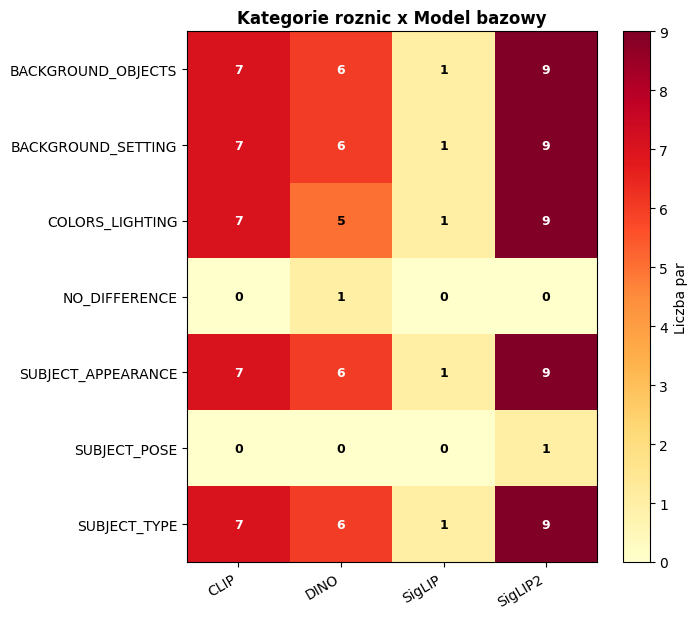


Suma per kategoria:


,liczba_par
category,
BACKGROUND_OBJECTS,23
BACKGROUND_SETTING,23
SUBJECT_APPEARANCE,23
SUBJECT_TYPE,23
COLORS_LIGHTING,22
NO_DIFFERENCE,1
SUBJECT_POSE,1


In [13]:
rows_exp = []
for _, row in cat_df.iterrows():
    for cat in str(row["categories"]).split("|"):
        cat = cat.strip()
        if cat and cat != "UNKNOWN":
            rows_exp.append({"base_name": row["base_name"], "category": cat})

exp_df = pd.DataFrame(rows_exp)
if exp_df.empty:
    print("Brak danych do wizualizacji.")
else:
    pivot = exp_df.groupby(["category", "base_name"]).size().unstack(fill_value=0)
    vmax  = pivot.values.max()
    fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns) * 1.8), max(4, len(pivot) * 0.9)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            color = "white" if vmax > 0 and val > vmax * 0.6 else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=9,
                    fontweight="bold", color=color)
    plt.colorbar(im, ax=ax, label="Liczba par")
    ax.set_title("Kategorie roznic x Model bazowy", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nSuma per kategoria:")
    ipy_display(
        exp_df.groupby("category").size().sort_values(ascending=False)
        .rename("liczba_par").to_frame()
    )

## 13. Przykładowe pary per kategoria


SUBJECT_TYPE  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


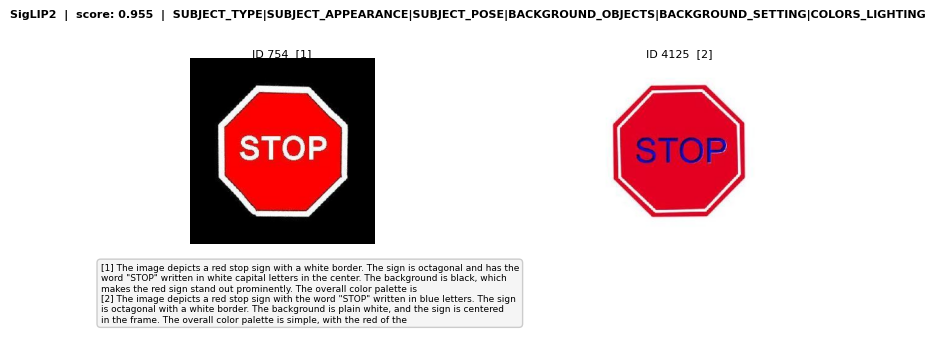

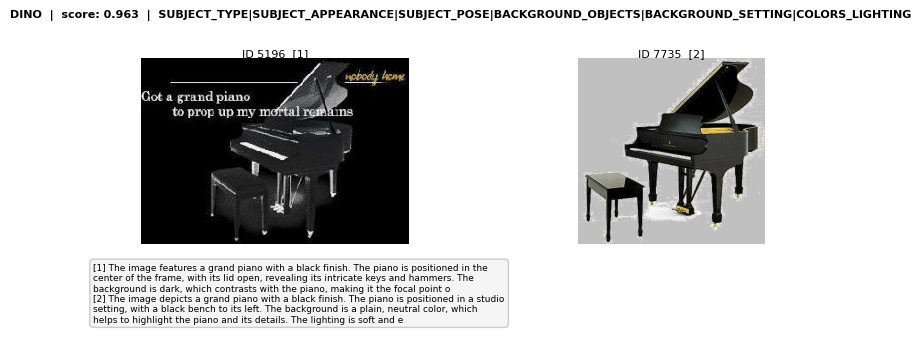



SUBJECT_APPEARANCE  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


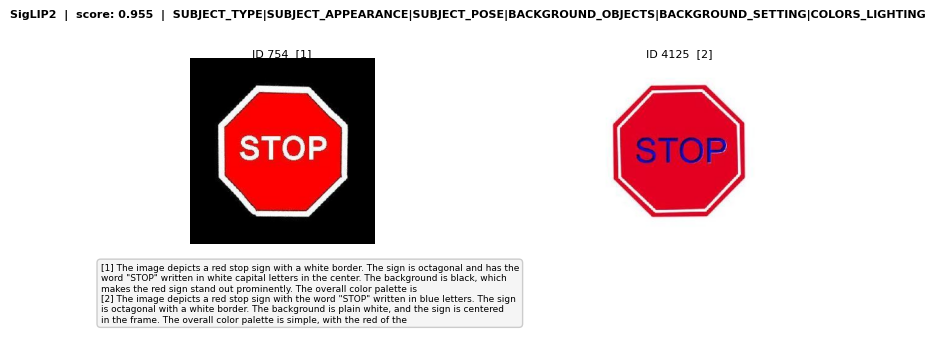

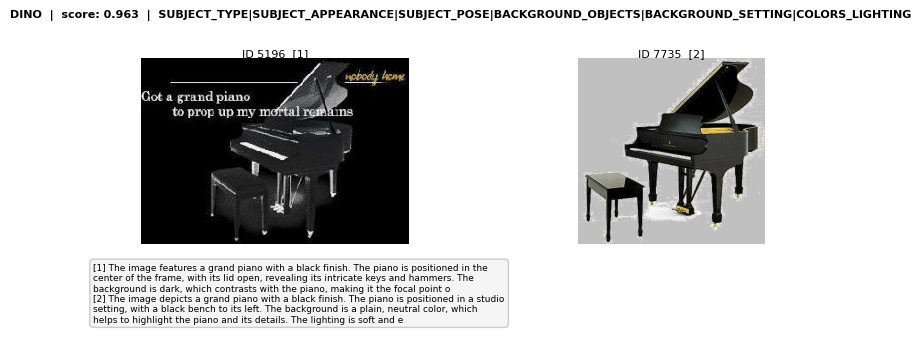



SUBJECT_POSE  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


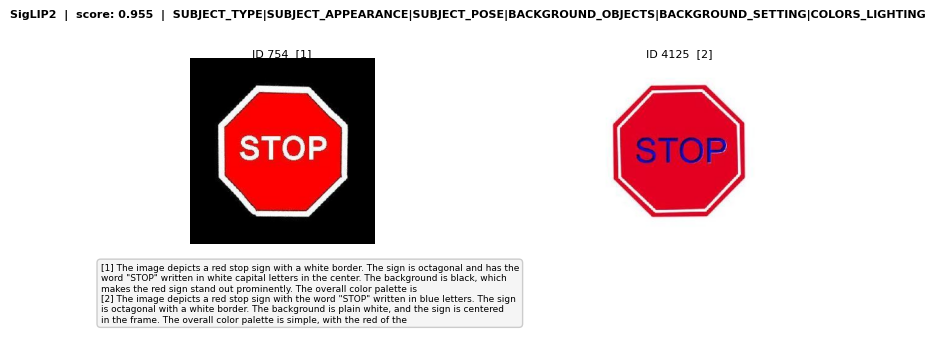

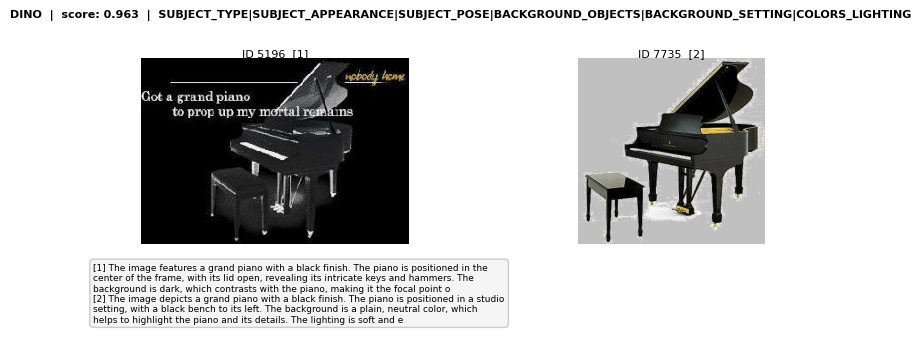



BACKGROUND_OBJECTS  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


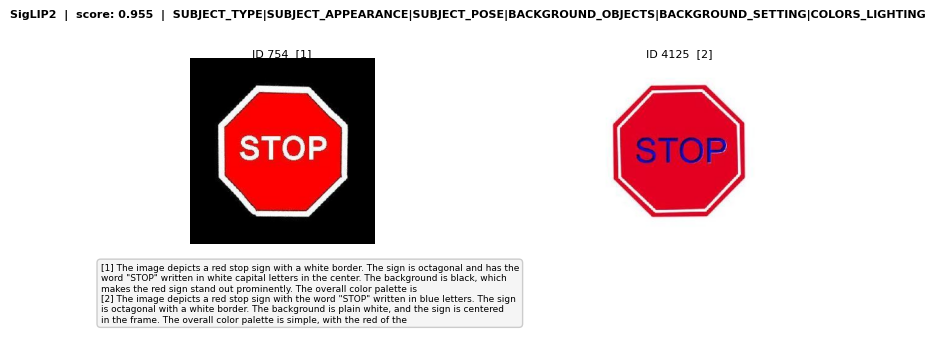

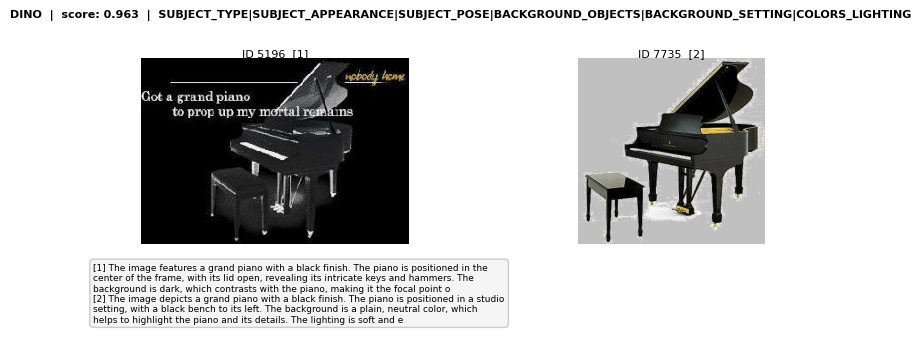



BACKGROUND_SETTING  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


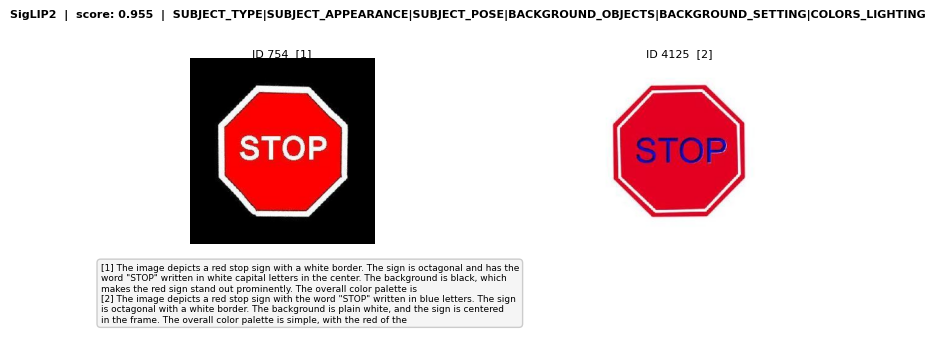

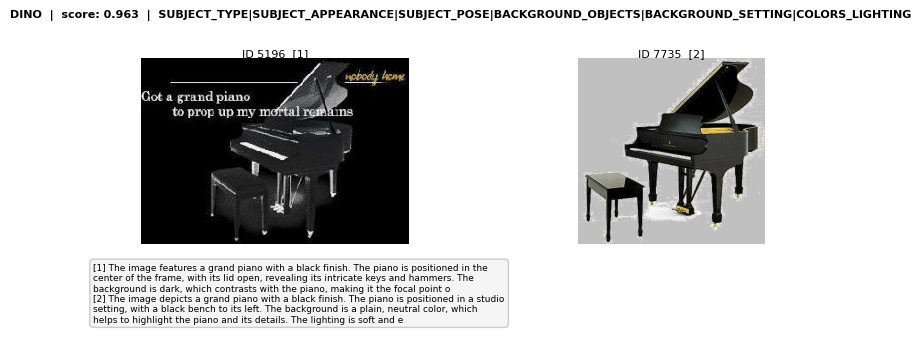



COLORS_LIGHTING  (23 par lacznie)


C:\Users\alapr\AppData\Local\Temp\ipykernel_26832\200622364.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


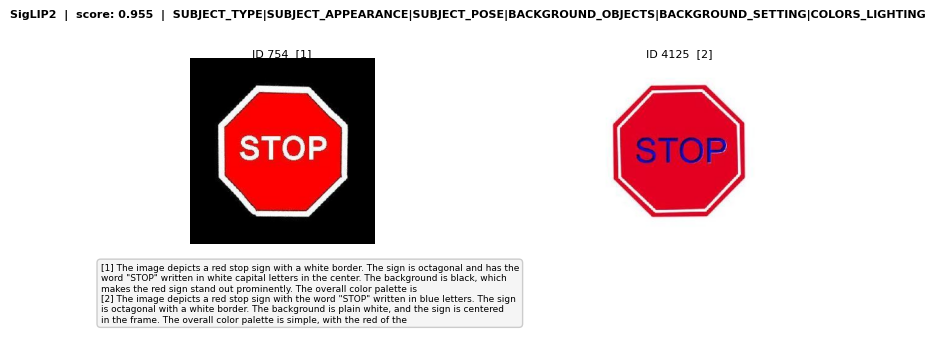

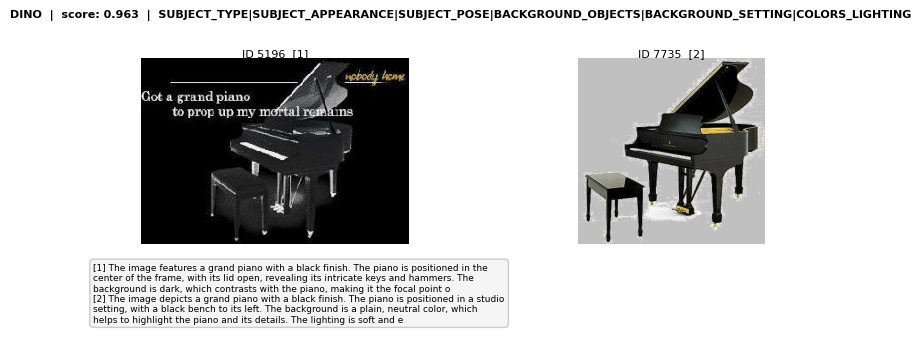

In [ ]:
DISPLAY_N_PER_CAT = 2

for cat in CATEGORIES:
    if cat == "NO_DIFFERENCE":
        continue
    subset = cat_df[cat_df["categories"].str.contains(cat, na=False)]
    if subset.empty:
        continue
    sample = subset.sample(n=min(DISPLAY_N_PER_CAT, len(subset)), random_state=42).reset_index(drop=True)
    sep = "=" * 60
    print(f"\n{sep}\n{cat}  ({len(subset)} par lacznie)\n{sep}")
    for _, row in sample.iterrows():
        key = "caltech" if "caltech" in str(row.get("source_file", "")) else "imagenet"
        try:
            img1 = Image.open(CACHE_DIR / key / f"{int(row['id_1'])}.jpg")
            img2 = Image.open(CACHE_DIR / key / f"{int(row['id_2'])}.jpg")
        except FileNotFoundError:
            print(f"  Brak obrazka dla pary {int(row['id_1'])}-{int(row['id_2'])}")
            continue
        fig = plt.figure(figsize=(10, 3.8))
        gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 3], hspace=0.1, wspace=0.05)
        for col, (img, lbl) in enumerate([
            (img1, f"ID {int(row['id_1'])}  [1]"),
            (img2, f"ID {int(row['id_2'])}  [2]"),
        ]):
            ax_img = fig.add_subplot(gs[0, col])
            ax_img.imshow(img)
            ax_img.set_title(lbl, fontsize=8, pad=2)
            ax_img.axis("off")
        ax_txt = fig.add_subplot(gs[1, :])
        ax_txt.axis("off")
        d1 = textwrap.fill(str(row.get("desc_1", ""))[:600], width=90)
        d2 = textwrap.fill(str(row.get("desc_2", ""))[:600], width=90)
        ax_txt.text(
            0.01, 0.95, f"[1] {d1}\n[2] {d2}",
            ha="left", va="top", fontsize=6.5,
            bbox=dict(facecolor="#f5f5f5", edgecolor="#ccc", boxstyle="round,pad=0.4"),
            transform=ax_txt.transAxes,
        )
        plt.suptitle(
            f"{row['base_name']}  |  score: {row['score_base']:.3f}  |  {row['categories']}",
            fontsize=8, fontweight="bold", y=1.01,
        )
        plt.tight_layout()
        plt.show()
        print()